Overview

This visualization explores the relationship between Spotify’s internal performance metrics and actual streaming dominance for the most streamed songs of 2024. Specifically, it examines whether Spotify Popularity and Track Score are sufficient to explain why certain songs become mega-hits in terms of total Spotify streams

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df = pd.read_csv("/content/dataspotify.csv", encoding="latin-1")
df.head()



,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [22]:
df.columns

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts',
       'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach',
       'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins',
       'Deezer Playlist Count', 'Deezer Playlist Reach',
       'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations',
       'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity',
       'Explicit Track'],
      dtype='object')

In [23]:
needed_cols = [
    'Track',
    'Spotify Popularity',
    'Track Score',
    'Spotify Streams',
    'Explicit Track'
]

df_viz = df[needed_cols].copy()
df_viz.head()


,Track,Spotify Popularity,Track Score,Spotify Streams,Explicit Track
0,MILLION DOLLAR BABY,92.0,725.4,"390,470,936",0
1,Not Like Us,92.0,545.9,"323,703,884",1
2,i like the way you kiss me,92.0,538.4,"601,309,283",0
3,Flowers,85.0,444.9,"2,031,280,633",0
4,Houdini,88.0,423.3,"107,034,922",1


In [24]:
df_viz['Spotify Streams'] = (
    df_viz['Spotify Streams']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_viz['Spotify Streams'] = pd.to_numeric(df_viz['Spotify Streams'], errors='coerce')

# drop rows where streams are missing or invalid
df_viz = df_viz.dropna(subset=['Spotify Streams'])
df_viz['Spotify Streams'].dtype


dtype('float64')

In [25]:
df_viz['Explicit Track'] = pd.to_numeric(df_viz['Explicit Track'], errors='coerce').fillna(0).astype(int)
df_viz['Explicit Track'].value_counts()


,count
Explicit Track,
0,2845
1,1642


In [26]:
df_viz['Spotify Popularity'] = pd.to_numeric(df_viz['Spotify Popularity'], errors='coerce')
df_viz['Track Score'] = pd.to_numeric(df_viz['Track Score'], errors='coerce')

df_viz = df_viz.dropna(subset=['Spotify Popularity', 'Track Score'])

df_viz['log_streams'] = np.log10(df_viz['Spotify Streams'])
df_viz[['Spotify Streams', 'log_streams']].head()


,Spotify Streams,log_streams
0,3.904709e+08,8.591589
1,3.237039e+08,8.510148
2,6.013093e+08,8.779098
3,2.031281e+09,9.307770
4,1.070349e+08,8.029525


In [29]:
top_hits = df_viz.nlargest(2, 'Spotify Streams').reset_index(drop=True)
top_hits[['Track', 'Spotify Popularity', 'Track Score', 'Spotify Streams']]


,Track,Spotify Popularity,Track Score,Spotify Streams
0,Blinding Lights,83.0,194.0,4.281469e+09
1,Shape of You,80.0,195.1,3.909459e+09


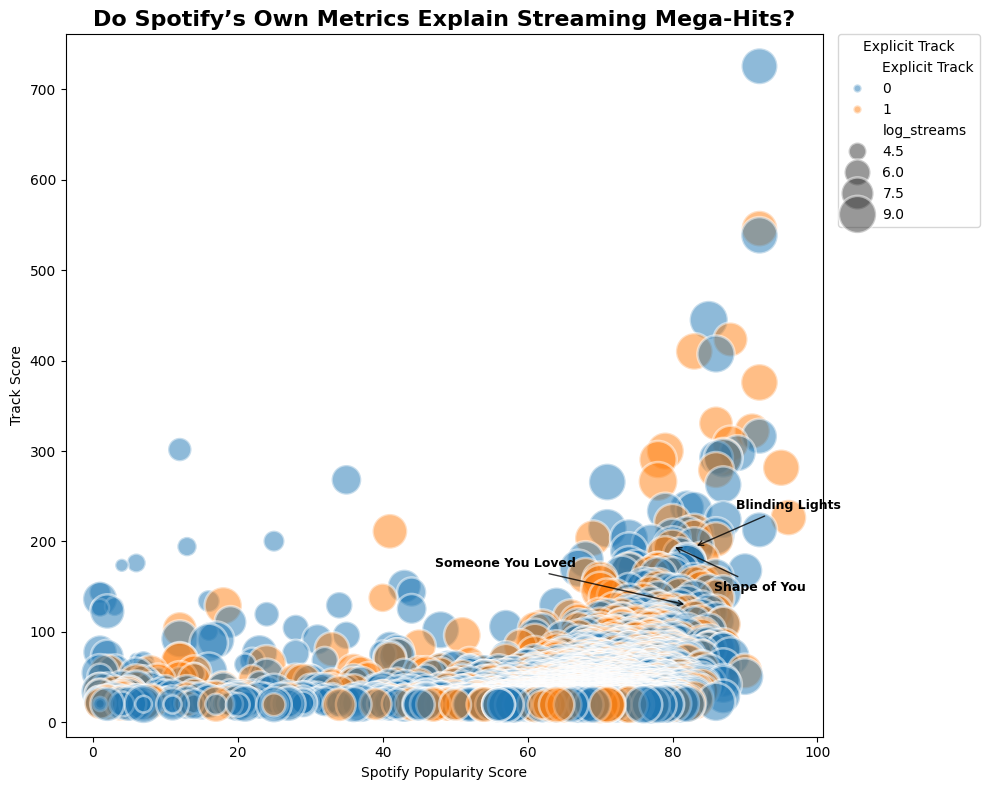

In [31]:

top_hits = df_viz.nlargest(3, 'Spotify Streams').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_viz,
    x='Spotify Popularity',
    y='Track Score',
    size='log_streams',
    hue='Explicit Track',
    sizes=(20, 800),          # slightly smaller max reduces clutter
    alpha=0.50,               # lower alpha reduces the “wall”
    ax=ax
)

offsets = [(30, 25), (30, -25), (-80, 25)]  # tweak if needed

for i in range(len(top_hits)):
    x = top_hits.loc[i, 'Spotify Popularity']
    y = top_hits.loc[i, 'Track Score']
    label = str(top_hits.loc[i, 'Track'])

    dx, dy = offsets[i]

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        weight='bold',
        ha='left' if dx >= 0 else 'right',
        va='bottom' if dy >= 0 else 'top',
        arrowprops=dict(arrowstyle='->', lw=1, alpha=0.8)
    )

ax.set_title("Do Spotify’s Own Metrics Explain Streaming Mega-Hits?",
             fontsize=16, weight='bold')
ax.set_xlabel("Spotify Popularity Score")
ax.set_ylabel("Track Score")

ax.legend(title="Explicit Track", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()


Interpretation

The visualization suggests that Spotify’s internal metrics are informative but incomplete predictors of mega-hit success. While platform scores capture important engagement signals, the most extreme streaming outcomes likely depend on additional factors beyond Spotify’s internal measurements, such as cultural moments, cross-platform exposure, or sustained listener behavior.